In [1]:
import os

os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

from importlib import reload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import utils.paths as paths

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


In [2]:
import data.utils as dutil

pointings = dutil.list_mosaics()

pointing = pointings[0]

arr, _ = dutil.load_mosaic(pointing, get_wcs=False)

from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

arr_scaled = scaler.scale(arr)

In [13]:
from plotting.maps import plot_sky_map
from plotting.images import plot_image_grid
from astropy.stats import sigma_clipped_stats

sigma = 5
mean, median, std = sigma_clipped_stats(arr, sigma=sigma, maxiters=None)

In [ ]:
source_mask = arr > (median + sigma * std)

import plotting.maps
reload(plotting.maps)
from plotting.maps import double_map_plot

%matplotlib widget
fig, axs = double_map_plot(
    arr_scaled * source_mask,
    arr_scaled * (1 - source_mask),
    colorbar=False,
    norm_quantile=None,

)

In [7]:
import bdsf
from analysis.bdsf_analysis import *


def run_islands(
    img,
    tmpdir=paths.ANALYSIS_PARENT / "tmp",
    beam_size_arcsec=6,
    wcs=None,
    set_quiet=True,
    **bdsf_kwargs,
):

    img = img.squeeze()

    # Create a temporary file
    with tempfile.NamedTemporaryFile(suffix=".fits", dir=tmpdir) as f:

        # Write the hdu to tmp fits file
        write_to_fits(img, f.name, wcs=wcs)

        # make bdsf op list
        op_list = [
            bdsf.readimage.Op_readimage,
            bdsf.collapse.Op_collapse,
            bdsf.preprocess.Op_preprocess,
            bdsf.rmsimage.Op_rmsimage,
            bdsf.threshold.Op_threshold,
            bdsf.islands.Op_islands,
        ]

        img = bdsf.image.Image({"filename": f.name})
        logging.USERINFO = logging.INFO + 1
        img.log = str(Path(f.name).with_suffix(".pybdsf.log"))
        img.opts.quiet = set_quiet
        img.opts.beam = (beam_size_arcsec / 3600, beam_size_arcsec / 3600, 0)
        if len(bdsf_kwargs) > 0:
            bdsf.interface.set_pars(img, **bdsf_kwargs)
        bdsf._run_op_list(img, op_list)

        # os.remove(f"{f.name}.pybdsf.log")

    return img

In [27]:
import bdsf

reload(bdsf)
import analysis.bdsf_analysis as bdsfa

reload(bdsfa)

default_kw = bdsfa.DEFAULT_KWARGS.copy()
default_kw["thresh_isl"] = 1.5
bdsf_img = run_islands(arr, set_quiet=False, **default_kw)

In [26]:
default_kw

{'thresh_isl': 3.0,
 'thresh_pix': 4.5,
 'thresh': None,
 'rms_box': (150, 15),
 'rms_map': True,
 'mean_map': 'zero',
 'ini_method': 'intensity',
 'adaptive_rms_box': True,
 'adaptive_thresh': 150,
 'rms_box_bright': (60, 15),
 'group_by_isl': False,
 'group_tol': 10.0,
 'output_opts': False,
 'output_all': False,
 'atrous_do': True,
 'atrous_jmax': 4,
 'flagging_opts': True,
 'flag_maxsize_fwhm': 0.5,
 'advanced_opts': True,
 'blank_limit': None,
 'frequency': 144000000.0,
 'debug': False,
 'quiet': False}

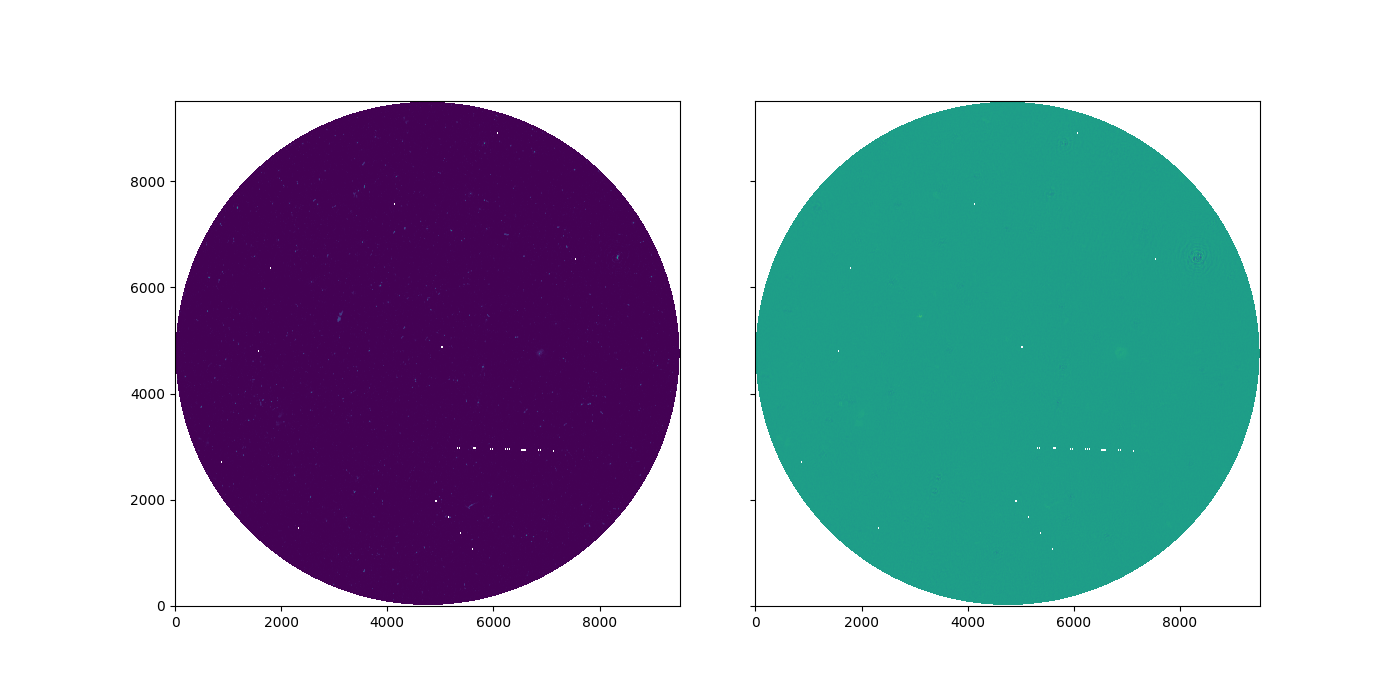

In [28]:
source_mask = bdsf_img.island_labels.T > 0

import plotting.maps
reload(plotting.maps)
from plotting.maps import double_map_plot

%matplotlib widget
fig, axs = double_map_plot(
    arr_scaled * source_mask,
    arr_scaled * (1 - source_mask),
    colorbar=False,
    norm_quantile=None,

)